<a href="https://colab.research.google.com/github/Madankk-06/Generative_AI_Projects/blob/main/5_CustomTransformer_Backpropagation_%26_Multi_Head_Gradient_Tracking_Engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import numpy as np
import torch
import matplotlib.pyplot as plt

np.random.seed(42)
torch.manual_seed(42)

In [23]:
torch.set_grad_enabled(False)

print("Autograd Enabled:", torch.is_grad_enabled())

Autograd Enabled: False


In [24]:
SEQ_LEN = 8
EMBED_DIM = 16

X = np.random.randn(SEQ_LEN, EMBED_DIM)

target = np.random.randn(SEQ_LEN, EMBED_DIM)

print(X.shape)

(8, 16)


In [25]:
Wq = np.random.randn(EMBED_DIM, EMBED_DIM) * 0.1
Wk = np.random.randn(EMBED_DIM, EMBED_DIM) * 0.1
Wv = np.random.randn(EMBED_DIM, EMBED_DIM) * 0.1

In [26]:
def softmax(x):
    x = x - np.max(x, axis=-1, keepdims=True)
    exp = np.exp(x)
    return exp / np.sum(exp, axis=-1, keepdims=True)

In [27]:
def forward(X):

    Q = X @ Wq

    K = X @ Wk

    V = X @ Wv

    scores = Q @ K.T

    scores /= np.sqrt(EMBED_DIM)

    attention = softmax(scores)

    output = attention @ V

    cache = (Q,K,V,attention)

    return output, cache

In [28]:
def mse(output,target):

    return np.mean((output-target)**2)

In [29]:
def backward(X, target, output, cache):

    Q, K, V, A = cache

    dOutput = 2 * (output - target) / output.size

    dV = A.T @ dOutput

    dA = dOutput @ V.T

    dScores = dA * A * (1 - A)

    dScores /= np.sqrt(EMBED_DIM)

    dQ = dScores @ K

    dK = dScores.T @ Q

    dWq = X.T @ dQ

    dWk = X.T @ dK

    dWv = X.T @ dV

    return dWq, dWk, dWv

In [30]:
lr = 0.01

losses = []

grad_q = []
grad_k = []
grad_v = []

for epoch in range(100):

    output,cache = forward(X)

    loss = mse(output,target)

    losses.append(loss)

    dWq,dWk,dWv = backward(X,target,output,cache)

    grad_q.append(np.linalg.norm(dWq))
    grad_k.append(np.linalg.norm(dWk))
    grad_v.append(np.linalg.norm(dWv))

    Wq -= lr*dWq
    Wk -= lr*dWk
    Wv -= lr*dWv

    if epoch%10==0:
        print(f"Epoch {epoch} Loss {loss:.6f}")

Epoch 0 Loss 1.003945
Epoch 10 Loss 0.998839
Epoch 20 Loss 0.993957
Epoch 30 Loss 0.989288
Epoch 40 Loss 0.984820
Epoch 50 Loss 0.980542
Epoch 60 Loss 0.976444
Epoch 70 Loss 0.972515
Epoch 80 Loss 0.968747
Epoch 90 Loss 0.965131


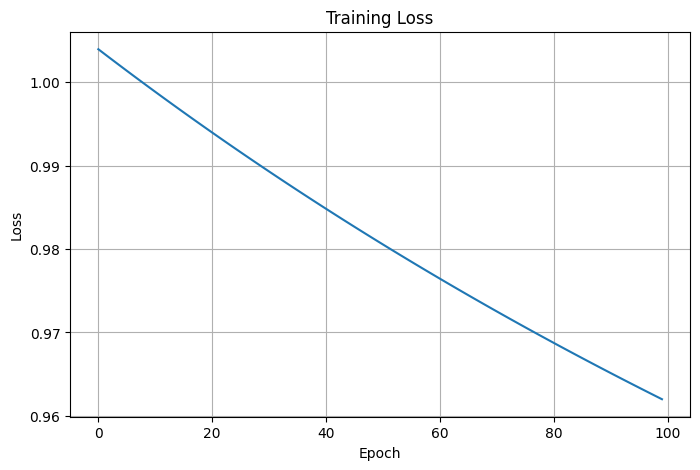

In [31]:
plt.figure(figsize=(8,5))

plt.plot(losses)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training Loss")

plt.grid()

plt.show()

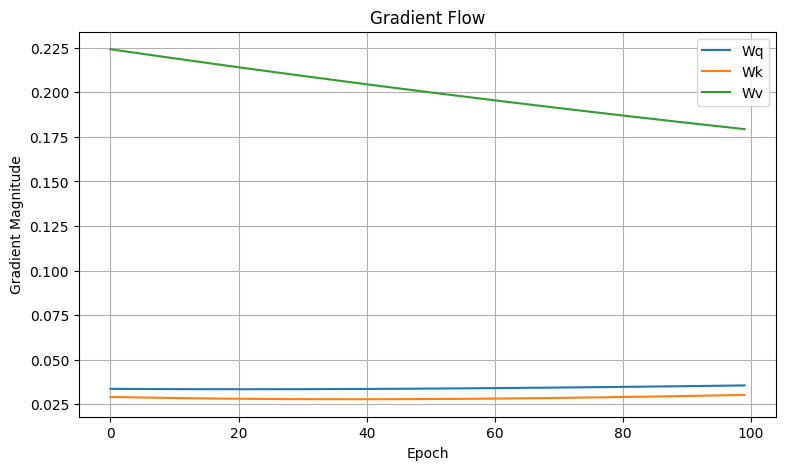

In [32]:
plt.figure(figsize=(9,5))

plt.plot(grad_q,label="Wq")

plt.plot(grad_k,label="Wk")

plt.plot(grad_v,label="Wv")

plt.xlabel("Epoch")

plt.ylabel("Gradient Magnitude")

plt.title("Gradient Flow")

plt.legend()

plt.grid()

plt.show()

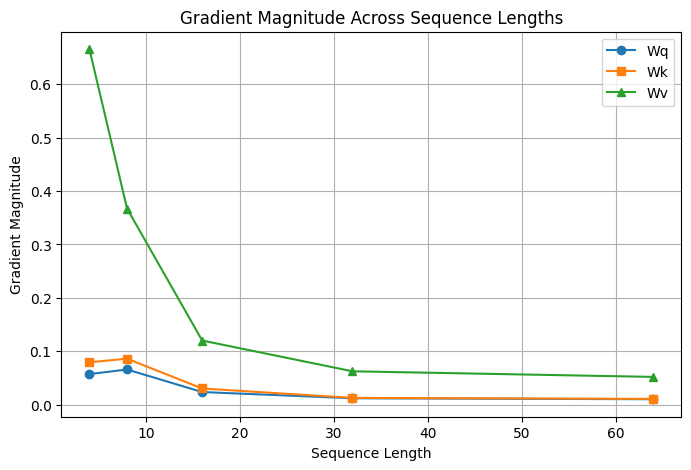

In [33]:
sequence_lengths = [4, 8, 16, 32, 64]

gradient_norms = []

for seq in sequence_lengths:

    X = np.random.randn(seq, EMBED_DIM)
    target = np.random.randn(seq, EMBED_DIM)

    output, cache = forward(X)

    dWq, dWk, dWv = backward(X, target, output, cache)

    gradient_norms.append([
        np.linalg.norm(dWq),
        np.linalg.norm(dWk),
        np.linalg.norm(dWv)
    ])

gradient_norms = np.array(gradient_norms)

plt.figure(figsize=(8,5))
plt.plot(sequence_lengths, gradient_norms[:,0], marker='o', label="Wq")
plt.plot(sequence_lengths, gradient_norms[:,1], marker='s', label="Wk")
plt.plot(sequence_lengths, gradient_norms[:,2], marker='^', label="Wv")

plt.xlabel("Sequence Length")
plt.ylabel("Gradient Magnitude")
plt.title("Gradient Magnitude Across Sequence Lengths")
plt.legend()
plt.grid()
plt.show()